In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer

In [2]:
df = pd.read_csv(r"D:\Python\ML\30_DAYS_ML_DL\Project_1\data\raw\loan_data.xls")
df

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9573,0,all_other,0.1461,344.76,12.180755,10.39,672,10474.000000,215372,82.1,2,0,0,1
9574,0,all_other,0.1253,257.70,11.141862,0.21,722,4380.000000,184,1.1,5,0,0,1
9575,0,debt_consolidation,0.1071,97.81,10.596635,13.09,687,3450.041667,10036,82.9,8,0,0,1
9576,0,home_improvement,0.1600,351.58,10.819778,19.18,692,1800.000000,0,3.2,5,0,0,1


In [3]:
df_fe = df.copy()
df_fe

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9573,0,all_other,0.1461,344.76,12.180755,10.39,672,10474.000000,215372,82.1,2,0,0,1
9574,0,all_other,0.1253,257.70,11.141862,0.21,722,4380.000000,184,1.1,5,0,0,1
9575,0,debt_consolidation,0.1071,97.81,10.596635,13.09,687,3450.041667,10036,82.9,8,0,0,1
9576,0,home_improvement,0.1600,351.58,10.819778,19.18,692,1800.000000,0,3.2,5,0,0,1


In [4]:
missing = df_fe.isnull().sum().sort_values(ascending=False)
missing

credit.policy        0
purpose              0
int.rate             0
installment          0
log.annual.inc       0
dti                  0
fico                 0
days.with.cr.line    0
revol.bal            0
revol.util           0
inq.last.6mths       0
delinq.2yrs          0
pub.rec              0
not.fully.paid       0
dtype: int64

In [5]:
num_cols = df_fe.select_dtypes(include=['int64', 'float64']).columns
imputer = SimpleImputer(strategy='median')
df_fe[num_cols] = imputer.fit_transform(df_fe[num_cols])
num_cols

Index(['credit.policy', 'int.rate', 'installment', 'log.annual.inc', 'dti',
       'fico', 'days.with.cr.line', 'revol.bal', 'revol.util',
       'inq.last.6mths', 'delinq.2yrs', 'pub.rec', 'not.fully.paid'],
      dtype='str')

In [6]:
cat_cols = df_fe.select_dtypes(include=['str']).columns
imputer = SimpleImputer(strategy='most_frequent')
df_fe[cat_cols] = imputer.fit_transform(df_fe[cat_cols])
cat_cols

Index(['purpose'], dtype='str')

In [7]:
df_fe = pd.get_dummies(df_fe, drop_first=True)
df_fe

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,1.0,0.1189,829.10,11.350407,19.48,737.0,5639.958333,28854.0,52.1,0.0,0.0,0.0,0.0,False,True,False,False,False,False
1,1.0,0.1071,228.22,11.082143,14.29,707.0,2760.000000,33623.0,76.7,0.0,0.0,0.0,0.0,True,False,False,False,False,False
2,1.0,0.1357,366.86,10.373491,11.63,682.0,4710.000000,3511.0,25.6,1.0,0.0,0.0,0.0,False,True,False,False,False,False
3,1.0,0.1008,162.34,11.350407,8.10,712.0,2699.958333,33667.0,73.2,1.0,0.0,0.0,0.0,False,True,False,False,False,False
4,1.0,0.1426,102.92,11.299732,14.97,667.0,4066.000000,4740.0,39.5,0.0,1.0,0.0,0.0,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9573,0.0,0.1461,344.76,12.180755,10.39,672.0,10474.000000,215372.0,82.1,2.0,0.0,0.0,1.0,False,False,False,False,False,False
9574,0.0,0.1253,257.70,11.141862,0.21,722.0,4380.000000,184.0,1.1,5.0,0.0,0.0,1.0,False,False,False,False,False,False
9575,0.0,0.1071,97.81,10.596635,13.09,687.0,3450.041667,10036.0,82.9,8.0,0.0,0.0,1.0,False,True,False,False,False,False
9576,0.0,0.1600,351.58,10.819778,19.18,692.0,1800.000000,0.0,3.2,5.0,0.0,0.0,1.0,False,False,False,True,False,False


##### Creating New Features

In [8]:
df_fe['debt_income_ratio'] = (
    df['installment'] /
    df_fe['log.annual.inc'])
df_fe

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business,debt_income_ratio
0,1.0,0.1189,829.10,11.350407,19.48,737.0,5639.958333,28854.0,52.1,0.0,0.0,0.0,0.0,False,True,False,False,False,False,73.045842
1,1.0,0.1071,228.22,11.082143,14.29,707.0,2760.000000,33623.0,76.7,0.0,0.0,0.0,0.0,True,False,False,False,False,False,20.593491
2,1.0,0.1357,366.86,10.373491,11.63,682.0,4710.000000,3511.0,25.6,1.0,0.0,0.0,0.0,False,True,False,False,False,False,35.365143
3,1.0,0.1008,162.34,11.350407,8.10,712.0,2699.958333,33667.0,73.2,1.0,0.0,0.0,0.0,False,True,False,False,False,False,14.302571
4,1.0,0.1426,102.92,11.299732,14.97,667.0,4066.000000,4740.0,39.5,0.0,1.0,0.0,0.0,True,False,False,False,False,False,9.108180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9573,0.0,0.1461,344.76,12.180755,10.39,672.0,10474.000000,215372.0,82.1,2.0,0.0,0.0,1.0,False,False,False,False,False,False,28.303665
9574,0.0,0.1253,257.70,11.141862,0.21,722.0,4380.000000,184.0,1.1,5.0,0.0,0.0,1.0,False,False,False,False,False,False,23.128989
9575,0.0,0.1071,97.81,10.596635,13.09,687.0,3450.041667,10036.0,82.9,8.0,0.0,0.0,1.0,False,True,False,False,False,False,9.230289
9576,0.0,0.1600,351.58,10.819778,19.18,692.0,1800.000000,0.0,3.2,5.0,0.0,0.0,1.0,False,False,False,True,False,False,32.494196


In [9]:
df_fe['many_inquiries'] = (
    df_fe['inq.last.6mths'] >= 5
).astype(int)
df_fe

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,...,pub.rec,not.fully.paid,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business,debt_income_ratio,many_inquiries
0,1.0,0.1189,829.10,11.350407,19.48,737.0,5639.958333,28854.0,52.1,0.0,...,0.0,0.0,False,True,False,False,False,False,73.045842,0
1,1.0,0.1071,228.22,11.082143,14.29,707.0,2760.000000,33623.0,76.7,0.0,...,0.0,0.0,True,False,False,False,False,False,20.593491,0
2,1.0,0.1357,366.86,10.373491,11.63,682.0,4710.000000,3511.0,25.6,1.0,...,0.0,0.0,False,True,False,False,False,False,35.365143,0
3,1.0,0.1008,162.34,11.350407,8.10,712.0,2699.958333,33667.0,73.2,1.0,...,0.0,0.0,False,True,False,False,False,False,14.302571,0
4,1.0,0.1426,102.92,11.299732,14.97,667.0,4066.000000,4740.0,39.5,0.0,...,0.0,0.0,True,False,False,False,False,False,9.108180,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9573,0.0,0.1461,344.76,12.180755,10.39,672.0,10474.000000,215372.0,82.1,2.0,...,0.0,1.0,False,False,False,False,False,False,28.303665,0
9574,0.0,0.1253,257.70,11.141862,0.21,722.0,4380.000000,184.0,1.1,5.0,...,0.0,1.0,False,False,False,False,False,False,23.128989,1
9575,0.0,0.1071,97.81,10.596635,13.09,687.0,3450.041667,10036.0,82.9,8.0,...,0.0,1.0,False,True,False,False,False,False,9.230289,1
9576,0.0,0.1600,351.58,10.819778,19.18,692.0,1800.000000,0.0,3.2,5.0,...,0.0,1.0,False,False,False,True,False,False,32.494196,1


In [10]:
df_fe['has_delinquency'] = (
    df_fe['delinq.2yrs'] > 0
).astype(int)
df_fe

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,...,not.fully.paid,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business,debt_income_ratio,many_inquiries,has_delinquency
0,1.0,0.1189,829.10,11.350407,19.48,737.0,5639.958333,28854.0,52.1,0.0,...,0.0,False,True,False,False,False,False,73.045842,0,0
1,1.0,0.1071,228.22,11.082143,14.29,707.0,2760.000000,33623.0,76.7,0.0,...,0.0,True,False,False,False,False,False,20.593491,0,0
2,1.0,0.1357,366.86,10.373491,11.63,682.0,4710.000000,3511.0,25.6,1.0,...,0.0,False,True,False,False,False,False,35.365143,0,0
3,1.0,0.1008,162.34,11.350407,8.10,712.0,2699.958333,33667.0,73.2,1.0,...,0.0,False,True,False,False,False,False,14.302571,0,0
4,1.0,0.1426,102.92,11.299732,14.97,667.0,4066.000000,4740.0,39.5,0.0,...,0.0,True,False,False,False,False,False,9.108180,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9573,0.0,0.1461,344.76,12.180755,10.39,672.0,10474.000000,215372.0,82.1,2.0,...,1.0,False,False,False,False,False,False,28.303665,0,0
9574,0.0,0.1253,257.70,11.141862,0.21,722.0,4380.000000,184.0,1.1,5.0,...,1.0,False,False,False,False,False,False,23.128989,1,0
9575,0.0,0.1071,97.81,10.596635,13.09,687.0,3450.041667,10036.0,82.9,8.0,...,1.0,False,True,False,False,False,False,9.230289,1,0
9576,0.0,0.1600,351.58,10.819778,19.18,692.0,1800.000000,0.0,3.2,5.0,...,1.0,False,False,False,True,False,False,32.494196,1,0


In [11]:
df_fe['has_public_record'] = (
    df_fe['pub.rec'] > 0
).astype(int)
df_fe

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,...,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business,debt_income_ratio,many_inquiries,has_delinquency,has_public_record
0,1.0,0.1189,829.10,11.350407,19.48,737.0,5639.958333,28854.0,52.1,0.0,...,False,True,False,False,False,False,73.045842,0,0,0
1,1.0,0.1071,228.22,11.082143,14.29,707.0,2760.000000,33623.0,76.7,0.0,...,True,False,False,False,False,False,20.593491,0,0,0
2,1.0,0.1357,366.86,10.373491,11.63,682.0,4710.000000,3511.0,25.6,1.0,...,False,True,False,False,False,False,35.365143,0,0,0
3,1.0,0.1008,162.34,11.350407,8.10,712.0,2699.958333,33667.0,73.2,1.0,...,False,True,False,False,False,False,14.302571,0,0,0
4,1.0,0.1426,102.92,11.299732,14.97,667.0,4066.000000,4740.0,39.5,0.0,...,True,False,False,False,False,False,9.108180,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9573,0.0,0.1461,344.76,12.180755,10.39,672.0,10474.000000,215372.0,82.1,2.0,...,False,False,False,False,False,False,28.303665,0,0,0
9574,0.0,0.1253,257.70,11.141862,0.21,722.0,4380.000000,184.0,1.1,5.0,...,False,False,False,False,False,False,23.128989,1,0,0
9575,0.0,0.1071,97.81,10.596635,13.09,687.0,3450.041667,10036.0,82.9,8.0,...,False,True,False,False,False,False,9.230289,1,0,0
9576,0.0,0.1600,351.58,10.819778,19.18,692.0,1800.000000,0.0,3.2,5.0,...,False,False,False,True,False,False,32.494196,1,0,0


In [12]:
bins = [300, 580, 670, 752, 800, 840]
labels = [
    'poor',
    'fair',
    'good',
    'very good',
    'excellent'
]
df_fe['fico_category'] = pd.cut(
    df_fe['fico'],
    bins=bins,
    labels=labels
)
df_fe

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,...,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business,debt_income_ratio,many_inquiries,has_delinquency,has_public_record,fico_category
0,1.0,0.1189,829.10,11.350407,19.48,737.0,5639.958333,28854.0,52.1,0.0,...,True,False,False,False,False,73.045842,0,0,0,good
1,1.0,0.1071,228.22,11.082143,14.29,707.0,2760.000000,33623.0,76.7,0.0,...,False,False,False,False,False,20.593491,0,0,0,good
2,1.0,0.1357,366.86,10.373491,11.63,682.0,4710.000000,3511.0,25.6,1.0,...,True,False,False,False,False,35.365143,0,0,0,good
3,1.0,0.1008,162.34,11.350407,8.10,712.0,2699.958333,33667.0,73.2,1.0,...,True,False,False,False,False,14.302571,0,0,0,good
4,1.0,0.1426,102.92,11.299732,14.97,667.0,4066.000000,4740.0,39.5,0.0,...,False,False,False,False,False,9.108180,0,1,0,fair
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9573,0.0,0.1461,344.76,12.180755,10.39,672.0,10474.000000,215372.0,82.1,2.0,...,False,False,False,False,False,28.303665,0,0,0,good
9574,0.0,0.1253,257.70,11.141862,0.21,722.0,4380.000000,184.0,1.1,5.0,...,False,False,False,False,False,23.128989,1,0,0,good
9575,0.0,0.1071,97.81,10.596635,13.09,687.0,3450.041667,10036.0,82.9,8.0,...,True,False,False,False,False,9.230289,1,0,0,good
9576,0.0,0.1600,351.58,10.819778,19.18,692.0,1800.000000,0.0,3.2,5.0,...,False,False,True,False,False,32.494196,1,0,0,good


In [13]:
df_fe = pd.get_dummies(df_fe, drop_first=True)
df_fe

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,...,purpose_major_purchase,purpose_small_business,debt_income_ratio,many_inquiries,has_delinquency,has_public_record,fico_category_fair,fico_category_good,fico_category_very good,fico_category_excellent
0,1.0,0.1189,829.10,11.350407,19.48,737.0,5639.958333,28854.0,52.1,0.0,...,False,False,73.045842,0,0,0,False,True,False,False
1,1.0,0.1071,228.22,11.082143,14.29,707.0,2760.000000,33623.0,76.7,0.0,...,False,False,20.593491,0,0,0,False,True,False,False
2,1.0,0.1357,366.86,10.373491,11.63,682.0,4710.000000,3511.0,25.6,1.0,...,False,False,35.365143,0,0,0,False,True,False,False
3,1.0,0.1008,162.34,11.350407,8.10,712.0,2699.958333,33667.0,73.2,1.0,...,False,False,14.302571,0,0,0,False,True,False,False
4,1.0,0.1426,102.92,11.299732,14.97,667.0,4066.000000,4740.0,39.5,0.0,...,False,False,9.108180,0,1,0,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9573,0.0,0.1461,344.76,12.180755,10.39,672.0,10474.000000,215372.0,82.1,2.0,...,False,False,28.303665,0,0,0,False,True,False,False
9574,0.0,0.1253,257.70,11.141862,0.21,722.0,4380.000000,184.0,1.1,5.0,...,False,False,23.128989,1,0,0,False,True,False,False
9575,0.0,0.1071,97.81,10.596635,13.09,687.0,3450.041667,10036.0,82.9,8.0,...,False,False,9.230289,1,0,0,False,True,False,False
9576,0.0,0.1600,351.58,10.819778,19.18,692.0,1800.000000,0.0,3.2,5.0,...,False,False,32.494196,1,0,0,False,True,False,False


In [14]:
print(df_fe.columns.tolist())

['credit.policy', 'int.rate', 'installment', 'log.annual.inc', 'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util', 'inq.last.6mths', 'delinq.2yrs', 'pub.rec', 'not.fully.paid', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_educational', 'purpose_home_improvement', 'purpose_major_purchase', 'purpose_small_business', 'debt_income_ratio', 'many_inquiries', 'has_delinquency', 'has_public_record', 'fico_category_fair', 'fico_category_good', 'fico_category_very good', 'fico_category_excellent']


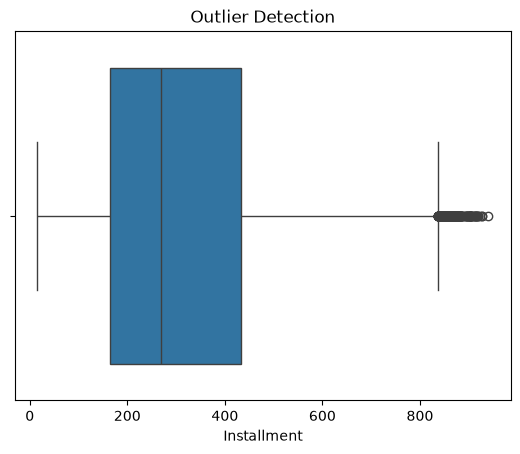

In [15]:
sns.boxplot(x=df_fe['installment'])
plt.xlabel("Installment")
plt.title("Outlier Detection")
plt.show()

In [16]:
df_fe.to_csv("../data/processed/loan_processed_data.csv", index=False)